<a href="https://colab.research.google.com/github/Sandyon1top/AI/blob/main/SandipDhakal_Worksheet4_Devnagari.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 6CS012 – Worksheet 4
## Fully Connected Neural Network – Devnagari Handwritten Digit Classification


---


Step 0 — Mount Google Drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Step 1 — Verify Dataset ,Copy Dataset from Drive to Local Disk





In [10]:
import shutil, os

DRIVE_TRAIN = '/content/drive/MyDrive/DevanagariHandwrittenDigitDataset/Train'
DRIVE_TEST  = '/content/drive/MyDrive/DevanagariHandwrittenDigitDataset/Test'

LOCAL_TRAIN = '/content/dataset/Train'
LOCAL_TEST  = '/content/dataset/Test'

if not os.path.isdir(LOCAL_TRAIN):
    print('Copying Train folder... (takes ~30 seconds)')
    shutil.copytree(DRIVE_TRAIN, LOCAL_TRAIN)
    print('Train done!')
else:
    print('Train already copied.')

if not os.path.isdir(LOCAL_TEST):
    print('Copying Test folder...')
    shutil.copytree(DRIVE_TEST, LOCAL_TEST)
    print('Test done!')
else:
    print('Test already copied.')

print('\nClasses in Train:', sorted(os.listdir(LOCAL_TRAIN)))
print('Classes in Test: ', sorted(os.listdir(LOCAL_TEST)))

Copying Train folder... (takes ~30 seconds)
Train done!
Copying Test folder...
Test done!

Classes in Train: ['digit_0', 'digit_1', 'digit_2', 'digit_3', 'digit_4', 'digit_5', 'digit_6', 'digit_7', 'digit_8', 'digit_9']
Classes in Test:  ['digit_0', 'digit_1', 'digit_2', 'digit_3', 'digit_4', 'digit_5', 'digit_6', 'digit_7', 'digit_8', 'digit_9']


 Step 2 — Import Libraries

In [12]:
import os
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt
from PIL import Image

print('TensorFlow version:', tf.__version__)
print('GPU available:', len(tf.config.list_physical_devices('GPU')) > 0)

TensorFlow version: 2.19.0
GPU available: False


Step 3 — Task 1: Load and Preprocess the Data

In [13]:
IMG_HEIGHT  = 28
IMG_WIDTH   = 28
NUM_CLASSES = 10

def load_images_from_folder(folder):
    images, labels = [], []
    class_names = sorted(os.listdir(folder))
    class_map   = {name: idx for idx, name in enumerate(class_names)}
    print(f'Loading from: {folder}')
    print(f'Classes: {class_names}')
    for class_name in class_names:
        class_path = os.path.join(folder, class_name)
        if not os.path.isdir(class_path):
            continue
        label = class_map[class_name]
        for filename in os.listdir(class_path):
            img_path = os.path.join(class_path, filename)
            try:
                img = Image.open(img_path).convert('L')       # grayscale
                img = img.resize((IMG_WIDTH, IMG_HEIGHT))      # 28x28
                images.append(np.array(img) / 255.0)          # normalise to [0,1]
                labels.append(label)
            except Exception:
                pass
    return np.array(images, dtype=np.float32), np.array(labels, dtype=np.int32)

print('Loading training images...')
x_train_raw, y_train_raw = load_images_from_folder(LOCAL_TRAIN)
print(f'  -> {x_train_raw.shape[0]} images loaded\n')

print('Loading test images...')
x_test_raw, y_test_raw = load_images_from_folder(LOCAL_TEST)
print(f'  -> {x_test_raw.shape[0]} images loaded')

Loading training images...
Loading from: /content/dataset/Train
Classes: ['digit_0', 'digit_1', 'digit_2', 'digit_3', 'digit_4', 'digit_5', 'digit_6', 'digit_7', 'digit_8', 'digit_9']
  -> 17000 images loaded

Loading test images...
Loading from: /content/dataset/Test
Classes: ['digit_0', 'digit_1', 'digit_2', 'digit_3', 'digit_4', 'digit_5', 'digit_6', 'digit_7', 'digit_8', 'digit_9']
  -> 3000 images loaded


Step 4 — Flatten and One-Hot Encode

In [14]:
# Flatten 28x28 images into 784-dimensional vectors
x_train = x_train_raw.reshape(-1, IMG_HEIGHT * IMG_WIDTH)
x_test  = x_test_raw.reshape(-1,  IMG_HEIGHT * IMG_WIDTH)

# One-hot encode labels: e.g. 3 -> [0,0,0,1,0,0,0,0,0,0]
y_train = to_categorical(y_train_raw, num_classes=NUM_CLASSES)
y_test  = to_categorical(y_test_raw,  num_classes=NUM_CLASSES)

print(f'x_train shape: {x_train.shape}')
print(f'y_train shape: {y_train.shape}')
print(f'x_test  shape: {x_test.shape}')
print(f'y_test  shape: {y_test.shape}')

x_train shape: (17000, 784)
y_train shape: (17000, 10)
x_test  shape: (3000, 784)
y_test  shape: (3000, 10)


Step 5 — Visualise Sample Images

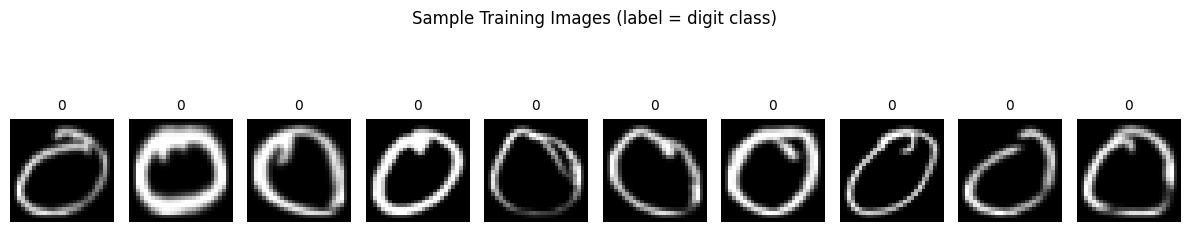

In [15]:
plt.figure(figsize=(12, 3))
for i in range(10):
    plt.subplot(1, 10, i + 1)
    plt.imshow(x_train_raw[i], cmap='gray')
    plt.title(str(y_train_raw[i]), fontsize=10)
    plt.axis('off')
plt.suptitle('Sample Training Images (label = digit class)', fontsize=12)
plt.tight_layout()
plt.show()

Step 6 — Task 2: Build the FCN Model

In [38]:
model = Sequential([
    keras.Input(shape=(IMG_HEIGHT * IMG_WIDTH,)),
    Dense(64,  activation='relu', name='hidden_layer_1'),
    Dense(128, activation='relu', name='hidden_layer_2'),
    Dense(256, activation='relu', name='hidden_layer_3'),
    Dense(NUM_CLASSES, activation='softmax', name='output_layer'),
], name='FCN_Devnagari')
model.summary()

Model: "FCN_Devnagari"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden_layer_1 (Dense)          │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_layer_2 (Dense)          │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_layer_3 (Dense)          │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 94,154 (367.79 KB)

 Trainable params: 94,154 (367.79 KB)

 Non-trainable params: 0 (0.00 B)

Step 7 — Task 3: Compile the Model

In [39]:
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
print('Model compiled successfully.')
print('  Optimizer : Adam')
print('  Loss      : categorical_crossentropy')
print('  Metric    : accuracy')

Model compiled successfully.
  Optimizer : Adam
  Loss      : categorical_crossentropy
  Metric    : accuracy


Step 8 — Task 4: Train the Model

In [40]:
BATCH_SIZE = 128
EPOCHS     = 20

callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath='best_model.keras',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    ),
    keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=4,
        restore_best_weights=True,
        verbose=1
    ),
]

history = model.fit(
    x_train, y_train,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    validation_split=0.2,
    callbacks=callbacks,
    verbose=1
)

print('\nTraining complete!')

Epoch 1/20
101/107 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6810 - loss: 0.9938
Epoch 1: val_accuracy improved from None to 0.00000, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8476 - loss: 0.4875 - val_accuracy: 0.0000e+00 - val_loss: 13.6717
Epoch 2/20
102/107 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9523 - loss: 0.1533
Epoch 2: val_accuracy did not improve from 0.00000
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9584 - loss: 0.1363 - val_accuracy: 0.0000e+00 - val_loss: 14.3388
Epoch 3/20
 97/107 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9747 - loss: 0.0888
Epoch 3: val_accuracy did not improve from 0.00000
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9748 - loss: 0.0819 - val_accuracy: 0.0000e+00 - val_loss: 14.3420
Epoch 4/20
 96/107 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9789 - loss: 0.0677
Epoch 4: val_accuracy did not improve from 0.00000

Step 9 — Plot Training Progress

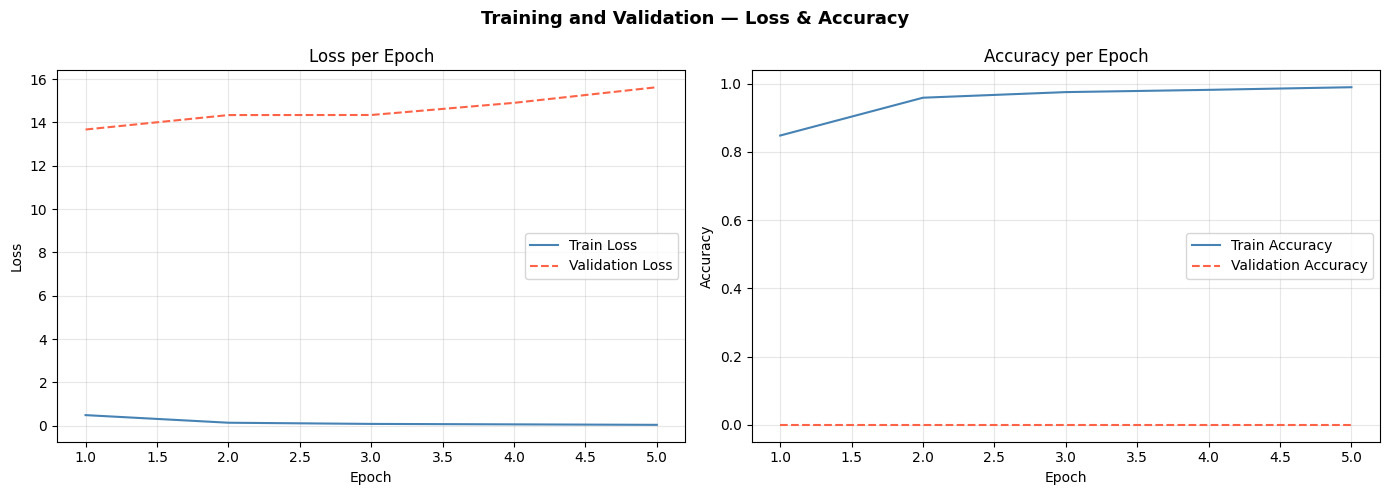

Graph saved as training_progress.png


In [41]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ep = range(1, len(history.history['loss']) + 1)

ax1.plot(ep, history.history['loss'],     label='Train Loss',      color='steelblue')
ax1.plot(ep, history.history['val_loss'], label='Validation Loss', color='tomato', linestyle='--')
ax1.set_title('Loss per Epoch')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(alpha=0.3)

ax2.plot(ep, history.history['accuracy'],     label='Train Accuracy',      color='steelblue')
ax2.plot(ep, history.history['val_accuracy'], label='Validation Accuracy', color='tomato', linestyle='--')
ax2.set_title('Accuracy per Epoch')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.legend()
ax2.grid(alpha=0.3)

plt.suptitle('Training and Validation — Loss & Accuracy', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('training_progress.png', dpi=150, bbox_inches='tight')
plt.show()
print('Graph saved as training_progress.png')

Step 10 — Task 5: Evaluate on Test Set

In [42]:
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=2)

print(f'\n======================================')
print(f'  Test Loss     : {test_loss:.4f}')
print(f'  Test Accuracy : {test_acc:.4f}  ({test_acc*100:.2f}%)')
print(f'======================================')

94/94 - 0s - 1ms/step - accuracy: 0.7457 - loss: 2.8783

  Test Loss     : 2.8783
  Test Accuracy : 0.7457  (74.57%)


Step 11 — Task 6: Save the Model

In [43]:
model.save('devnagari_fcn_model.h5')
print('Model saved as devnagari_fcn_model.h5')

Model saved as devnagari_fcn_model.h5


Step 12 — Task 6: Load the Model and Re-evaluate

In [44]:
loaded_model = tf.keras.models.load_model('devnagari_fcn_model.h5')
print('Model loaded successfully!')

loaded_loss, loaded_acc = loaded_model.evaluate(x_test, y_test, verbose=2)
print(f'\nLoaded model — Test Loss: {loaded_loss:.4f} | Test Accuracy: {loaded_acc*100:.2f}%')

Model loaded successfully!
94/94 - 0s - 5ms/step - accuracy: 0.7457 - loss: 2.8783

Loaded model — Test Loss: 2.8783 | Test Accuracy: 74.57%


Step 13 — Download the .h5 Model File

In [45]:
from google.colab import files
files.download('devnagari_fcn_model.h5')
print('Download started!')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Download started!


Step 14 — Task 7: Make Predictions

In [46]:
predictions      = model.predict(x_test, verbose=0)
predicted_labels = np.argmax(predictions, axis=1)
true_labels      = np.argmax(y_test, axis=1)

print(f'First image  — Predicted: {predicted_labels[0]}  |  True: {true_labels[0]}')
print(f'Overall test accuracy: {np.mean(predicted_labels == true_labels)*100:.2f}%')

First image  — Predicted: 0  |  True: 0
Overall test accuracy: 74.57%


Step 15 — Visualise Predictions

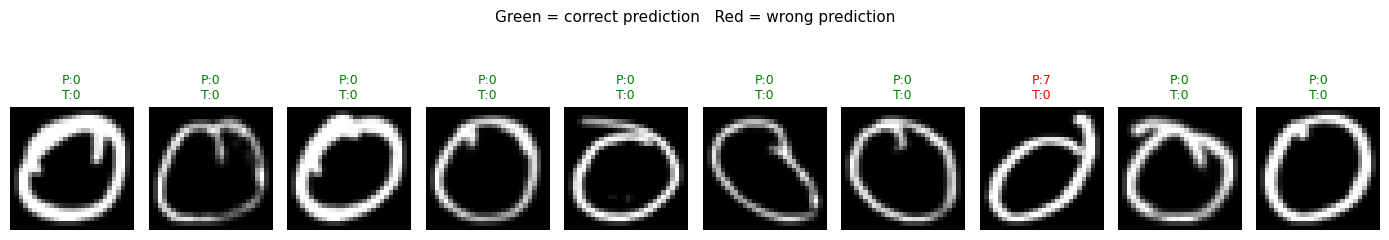

In [47]:
plt.figure(figsize=(14, 3))
for i in range(10):
    plt.subplot(1, 10, i + 1)
    plt.imshow(x_test_raw[i], cmap='gray')
    pred  = predicted_labels[i]
    true  = true_labels[i]
    color = 'green' if pred == true else 'red'
    plt.title(f'P:{pred}\nT:{true}', color=color, fontsize=9)
    plt.axis('off')
plt.suptitle('Green = correct prediction   Red = wrong prediction', fontsize=11)
plt.tight_layout()
plt.savefig('predictions.png', dpi=150, bbox_inches='tight')
plt.show()

Step 16 — Confusion Matrix

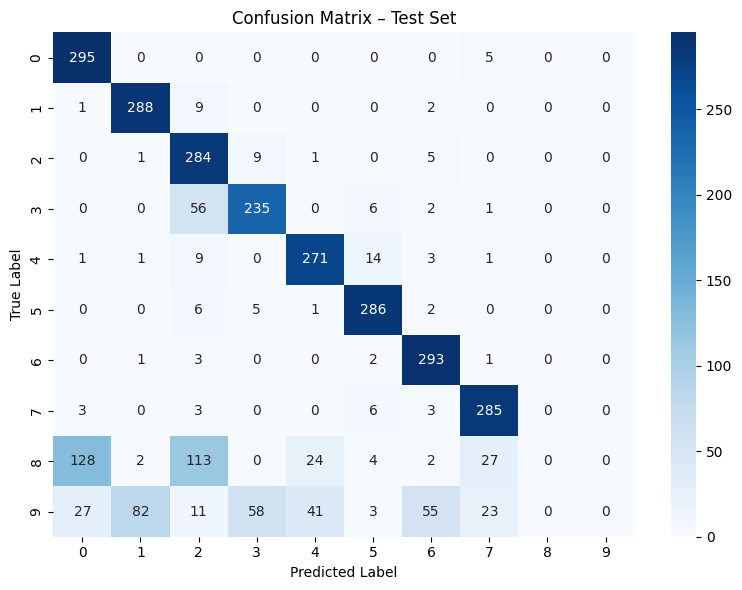


Classification Report:
              precision    recall  f1-score   support

     digit_0       0.65      0.98      0.78       300
     digit_1       0.77      0.96      0.85       300
     digit_2       0.57      0.95      0.72       300
     digit_3       0.77      0.78      0.77       300
     digit_4       0.80      0.90      0.85       300
     digit_5       0.89      0.95      0.92       300
     digit_6       0.80      0.98      0.88       300
     digit_7       0.83      0.95      0.89       300
     digit_8       0.00      0.00      0.00       300
     digit_9       0.00      0.00      0.00       300

    accuracy                           0.75      3000
   macro avg       0.61      0.75      0.67      3000
weighted avg       0.61      0.75      0.67      3000



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [48]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

cm = confusion_matrix(true_labels, predicted_labels)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=range(10), yticklabels=range(10))
plt.title('Confusion Matrix – Test Set')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nClassification Report:')
print(classification_report(true_labels, predicted_labels,
      target_names=[f'digit_{i}' for i in range(NUM_CLASSES)]))

---
## All Tasks Complete

| Task | What was done |
|------|---------------|
| Task 1 | Images loaded with PIL, normalised, one-hot encoded |
| Task 2 | FCN built: Dense(64) → Dense(128) → Dense(256) → Dense(10) |
| Task 3 | Compiled with Adam, categorical_crossentropy, accuracy |
| Task 4 | Trained with batch=128, epochs=20, validation_split=0.2, callbacks |
| Task 5 | Evaluated on test set — loss and accuracy printed |
| Task 6 | Saved as .h5, reloaded and re-evaluated |
| Task 7 | Predictions made, visualised, confusion matrix shown |